In [1]:
from cytograph import Algorithm, creates, requires, div0
from cytograph.visualization.scatter import scatterc, scattern
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from typing import List
import shoji
import cytograph as cg
import cytograph.visualization as cgplot
import collections
from typing import List, Optional
import matplotlib.patheffects as PathEffects
import fastcluster
import igraph
import leidenalg as la
import scipy.cluster.hierarchy as hc
from hmmlearn import hmm
from openTSNE import TSNE
from pynndescent import NNDescent
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from tqdm import trange
import pandas as pd
from cytograph.visualization import Colorizer
from matplotlib.lines import Line2D
import scanpy as sc
import loompy
import infercnvpy as cnv
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Connect to database
db = shoji.connect()

In [3]:
# Create a test workspace, and a subworkspace for holding an example dataset
db.builds.jesper.h5ad = shoji.Workspace() #Name it db.builds.'XXX'.'XXX'. Exchange "jesper.h5ad" to whatever you want to call it.
db.builds.jesper.h5ad.GBM_SL040 = shoji.Workspace()
ws = db.builds.jesper.h5ad.GBM_SL040

In [4]:
#Save h5ad file from url: https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/SL040.h5ad
#Alternatively follow the instructions at https://github.com/linnarsson-lab/shoji/blob/master/notebooks/GettingStarted_Shoji.ipynb under "Download example dataset" to create a temporary directory for the file.

In [5]:
# Load the sample data into your local Shoji database
ad = sc.read_h5ad('/home/jesper/data/SL040.h5ad') #Change to the path where the h5ad file has been saved 
ws.import_adata(ad, verbose=True)

In [6]:
#view
ad

AnnData object with n_obs × n_vars = 135482 × 59480
    obs: 'CellCycleFraction', 'Chemistry', 'Clusters', 'ClustersProbability', 'ClustersSecondary', 'ClustersSecondaryProbability', 'Direction', 'DoubletFlag', 'DoubletScore', 'Fluorescence', 'Location', 'ManualAnnotationSL040_TAM', 'ManualAnnotationSL040_central_peri', 'MitoFraction', 'NGenes', 'NeftelClass', 'Sample', 'SampleID', 'SignatureBootstrap', 'TotalUMIs', 'UnsplicedFraction', 'ValidCells', 'Zone', 'Aneuploid', 'ManualAnnotationSL040', 'ManualAnnotationSL040_Myeloid'
    var: 'Chromosome', 'End', 'Gene', 'GeneNonzeros', 'GeneTotalUMIs', 'SelectedFeatures', 'Start', 'StdevExpression', 'ValidGenes', 'Accession'
    obsm: 'Embedding', 'Factors', 'NeftelScore'
    layers: 'Expression'

In [7]:
#Change "astype"
Gene = np.array(ad.var.Gene)

In [8]:
ws.Gene = shoji.Tensor(dtype='string', dims=('genes',), inits=Gene.astype('object'))

In [9]:
Exp = ws.Expression[:]

In [10]:
ws.Expression = shoji.Tensor(dtype='uint16', dims=('cells', 'genes'), inits=Exp.astype('uint16'))

In [11]:
Emb = ad.obsm['Embedding']

In [12]:
ws.Embedding = shoji.Tensor(dtype='float32', dims=('cells', 2), inits=Emb.astype('float32'))

# Analyze multi-region SL40

## Figure 1

### Colors of choice (Fig 1a)

In [13]:
annotation_palette = {
'Astrocytes': '#4574B3',
'Oligodendrocytes':'#000000',

'B-cells': '#808080',
'Endothelial':'#808080',
'Fibroblasts':'#808080',
'NK, T-cells':'#808080',
'OPCs':'#808080',
'Pericytes':'#808080',
'VSMC':'#808080',

'MgTAM':'#B36305',
'MoTAM':'#FECB98',
'Microglia':'#EE7C0E',
'Monocytes':'#A580AD',
'Neuron':'#fabe58',
'Macrophages':'#C7BD80',

'Tumor':'#74C493',
}

### tSNE Fig 1a

In [14]:
ad.obsm["X_tsne"] =ad.obsm["Embedding"]

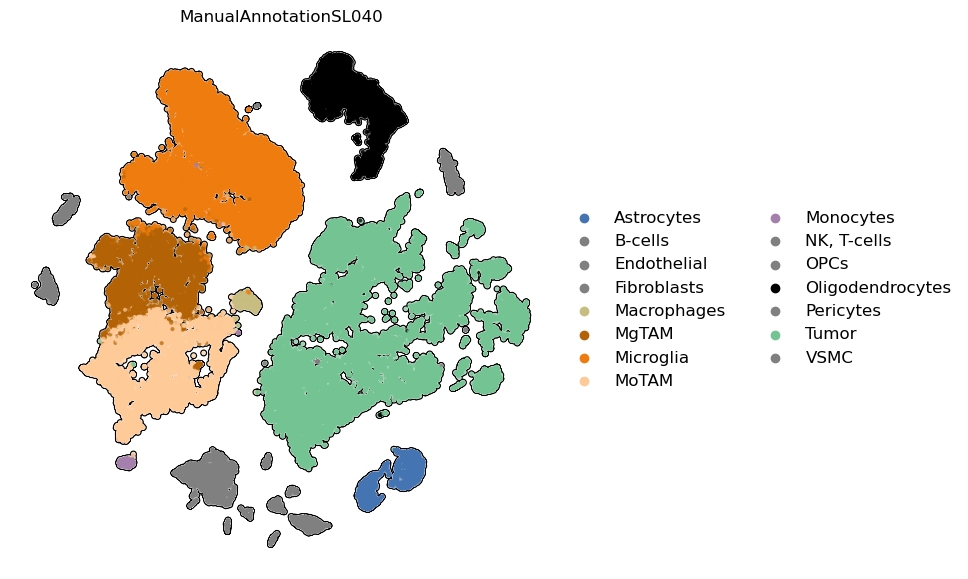

In [15]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

sc.pl.tsne(
ad,
color='ManualAnnotationSL040',
add_outline=True,
size=35,
legend_fontsize=12,
legend_fontoutline=2,
frameon=False,
palette=annotation_palette,
ax=ax,
show=False,
)
plt.show()

### tSNE with annotation for all cell types (not presented)

In [16]:
annotation_palette = {
'Astrocytes': '#4574B3',
'Oligodendrocytes':'#000000',

'B-cells': 'navy',
'Endothelial':'tomato',
'Fibroblasts':'gold',
'NK, T-cells':'cyan',
'OPCs':'silver',
'Pericytes':'lime',
'VSMC':'pink',

'MgTAM':'#B36305',
'MoTAM':'#FECB98',
'Microglia':'#EE7C0E',
'Monocytes':'#A580AD',
'Neuron':'#fabe58',
'Macrophages':'#C7BD80',

'Tumor':'#74C493',
}

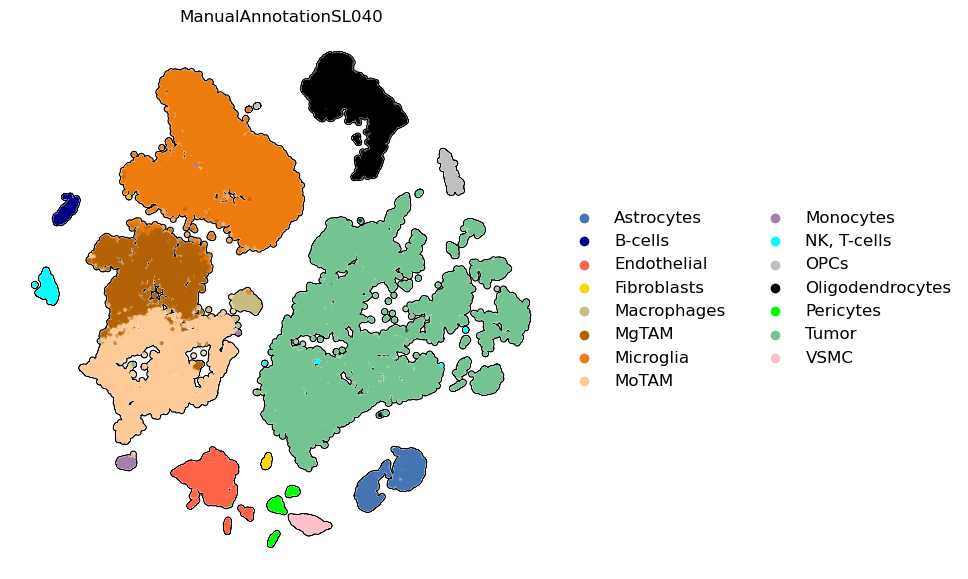

In [17]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

sc.pl.tsne(
ad,
color='ManualAnnotationSL040',
add_outline=True,
size=35,
legend_fontsize=12,
legend_fontoutline=2,
frameon=False,
palette=annotation_palette,
ax=ax,
show=False,
)
plt.show()

### Calc fraction of cell types (fig 1a)

In [18]:
palette_classes = {'Astrocytes':'#4574b3',
 'B-cells': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Fibroblasts': [0.296875, 0.0, 0.359375],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM':  "#b36305",                
 'Monocytes': "#a580ad",
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Pericytes': [0.7578125, 0.0, 0.53125],
 'Tumor': "#74c493",
 'VSMC': [0.99609375, 0.640625, 0.01953125]}

In [19]:
#Colors
Z =["#a580ad",
    "#c7bd80",
[0.99609375, 0.796875, 0.59765625],
 "#b36305", 
"#ee7c0e",
"#000000",
'#4574b3',
 "#74c493", 
'#848584'
]

In [20]:
#Cell types
labels2 = [
    'Monocytes',
    'Macrophages',
    'moTAM',
    'mgTAM',
    'Microglia',
    'Oligodendrocytes',
    'Astrocytes',
    'Tumor',
    'Other']

In [21]:
Right_order = ['Monocytes','Macrophages','MoTAM','MgTAM','Microglia','Oligodendrocytes','Astrocytes']

CPU times: user 8.15 s, sys: 2.67 s, total: 10.8 s
Wall time: 16.8 s


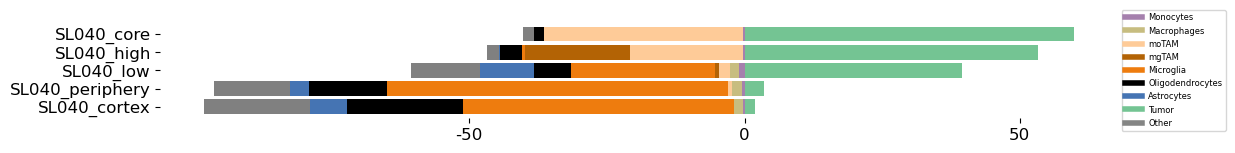

In [22]:
%%time
S = []
Samples = ['Necrotic core', 'High', 'Low', 'Periphery', 'Cortex'] #Location/Zones
unique_samples = ['SL040_core', 'SL040_high', 'SL040_low', 'SL040_periphery', 'SL040_cortex'] #Location/Zones displayed in plot
unique_samples = np.flip(unique_samples)
Samples = np.flip(Samples)
Samples = np.array(Samples, dtype=object)
unique_samples = np.array(unique_samples, dtype=object)
labels = np.unique(ws.ManualAnnotationSL040[:]) # all unique cell types
for i, sample in enumerate(Samples):
    Man = ws.ManualAnnotationSL040[:][ws.Fluorescence[:] == sample] #All cells in location
    Sum = []
    for x in labels: #loop through all cell types and count total
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum) #total number cells
    for x in Sum: #calc percentage of total for all cell types
        roundedNumber = round(x/tot * 100, 3) #round and multiply by 100 in order to show percentage
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop(['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC','Tumor'], axis=1) #All non-malignant cell types except "other"
other_bars = df[['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC']] #other"
tumor_bars = df[["Tumor"]] #tumor cells
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(10, 1.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True)
ax1.set_xticklabels([-50,0,50],fontsize=12)
#Plot percentage of different cell types (bars horizontal)
for i, ct in enumerate(Right_order):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=palette_classes[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(other_bars):
    ax1.barh(unique_samples,height=0.8, width=-other_bars[ct],left=-left, color=[0.5, 0.5, 0.5])
    left += other_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=palette_classes[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in Z]
ax1.legend(hidden_lines,labels2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None

### Calc Neftel-substates for all cells

In [20]:
#https://github.com/linnarsson-lab/cytograph-shoji/blob/main/cytograph/annotation/neftel_states.py
cg.NeftelStates().fit(ws, save=True)

INFO:root:Loading genes
INFO:root:Loading expression matrix
INFO:root:Normalizing to median total UMI
INFO:root:Calculating relative expression
INFO:root:Ordering genes by absolute expression
INFO:root:Computing signature scores
INFO:root: [Creating tensor NeftelClass of shape (135482,)]
INFO:root: [Creating tensor NeftelScore of shape (135482, 4)]


(array([[-5.12207971,  2.92527637, -0.78580633, -1.95661519],
        [-4.75231112,  6.48582729, -0.99332492, -2.41403939],
        [-4.69628196, 13.82130292, -0.85045719, -2.76133894],
        ...,
        [ 3.63762255,  0.53086907,  0.37425555, -0.08754248],
        [ 3.60092521, -2.32503653,  0.45062875,  1.93811526],
        [ 8.08259284, -1.8890592 ,  0.18257584,  1.27595787]]),
 array(['MES', 'MES', 'MES', ..., 'AC', 'AC', 'AC'], dtype='<U3'))

### Calc fraction of MES-type tumor cells (Fig 1a)

CPU times: user 8.28 s, sys: 2.73 s, total: 11 s
Wall time: 16.9 s


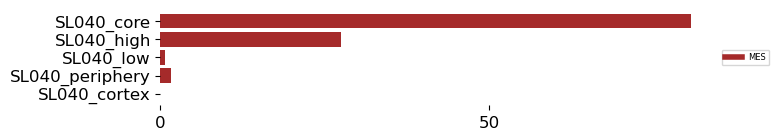

In [23]:
%%time
S = []
Samples = ['Necrotic core', 'High', 'Low', 'Periphery','Cortex'] #Location/Zones
unique_samples = ['SL040_core', 'SL040_high', 'SL040_low', 'SL040_periphery', 'SL040_cortex'] #Location/Zones displayed in plot
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = np.array(unique_samples, dtype=object)
unique_samples = np.flip(unique_samples)
A = ['AC', 'MES', 'NPC', 'OPC'] # Neftel substates
labels = np.array(A, dtype=object) 
for i, sample in enumerate(Samples):
    ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040[ws.Fluorescence[:] == sample] == 'Tumor'], 4) 
    winnersAll = np.argmax([ac, mes, npc, opc], axis=0) #The subtype with the highest score of the four is assigned to the cell
    Man = np.hstack(labels[winnersAll])
    Sum = []
    for x in labels: #loop through all states and count total
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum) #total number tumor cells
    for x in Sum: #calc percentage of total for all states
        roundedNumber = round(x/tot * 100, 3) #round and multiply by 100 in order to show percentage
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
tumor_bars = df[["MES"]] # only show MES-fraction
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True) 

ax1.set_xticklabels([-50,0,50],fontsize=12)
colors=["brown"]
labels = ['MES']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None

### Calc cell cycle fraction in tumor cells (Fig 1a)

CPU times: user 16.2 s, sys: 5.44 s, total: 21.7 s
Wall time: 33.4 s


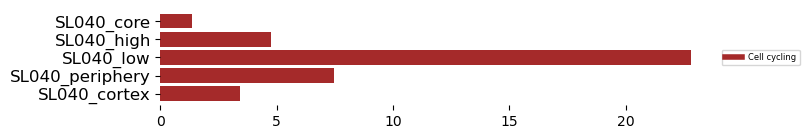

In [24]:
%%time
S = []
Samples = ['Necrotic core', 'High', 'Low', 'Periphery','Cortex'] #Location/Zones
unique_samples = ['SL040_core', 'SL040_high', 'SL040_low', 'SL040_periphery', 'SL040_cortex'] #Location/Zones displayed in plot
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = np.array(unique_samples, dtype=object)
unique_samples = np.flip(unique_samples)
for i, sample in enumerate(Samples):
    #Calc tumor cells that are cycling 
    Man = np.sum(ws.CellCycleFraction[ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040[ws.Fluorescence[:] == sample] == 'Tumor'] > 0.004)
    tot = len(ws.CellCycleFraction[ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040[ws.Fluorescence[:] == sample] == 'Tumor'])
    roundedNumber = round(Man/tot * 100, 3)
    Perc = str(roundedNumber) + "%"
    S.append(roundedNumber)
tumor_bars = pd.DataFrame(S, index=unique_samples)
tumor_bars = tumor_bars.rename(columns={0: 'Cell cycling'})
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.xaxis.set_visible(True) 

colors=["brown"]
labels = ['Cell cycling']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)
None

### Full list of MES1 and MES2 genes (concatenated)

In [25]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

### Colormap for relevant cell types across all MES-genes and zones (Fig 1b)

CPU times: user 1h 10min 9s, sys: 22min 28s, total: 1h 32min 37s
Wall time: 2h 13min 56s


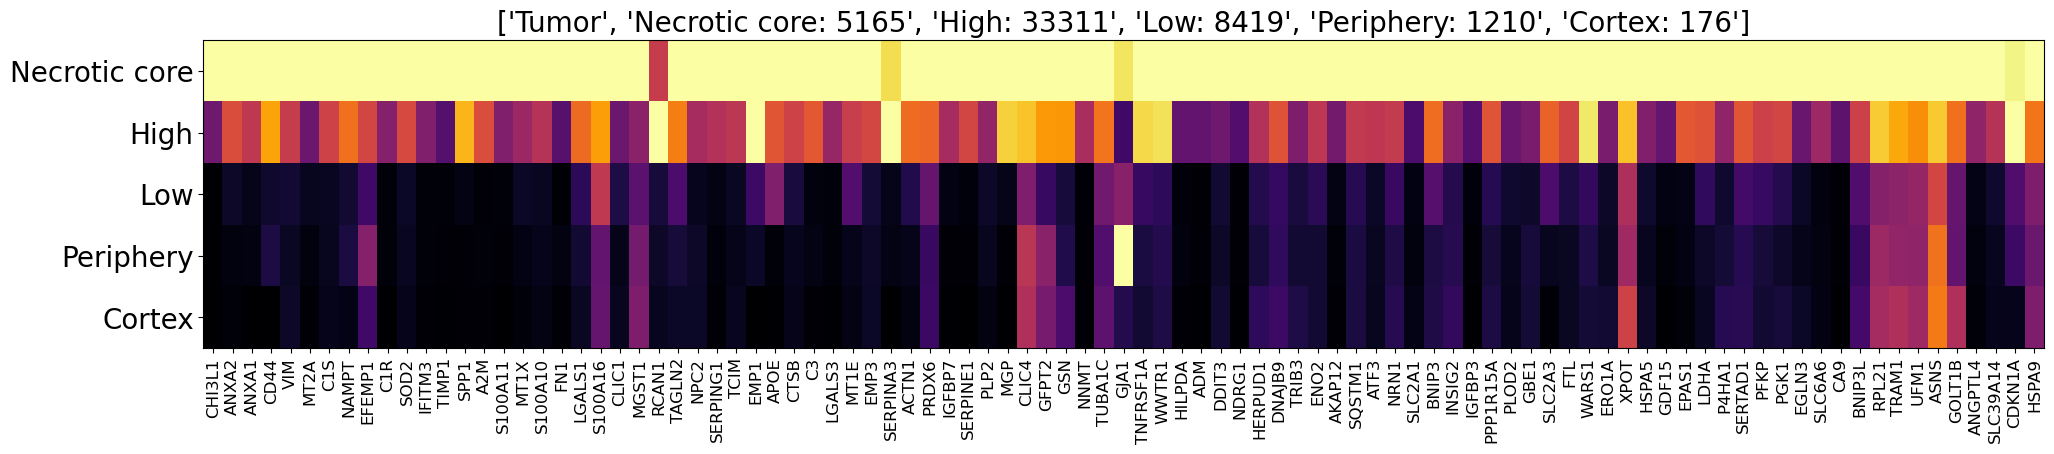

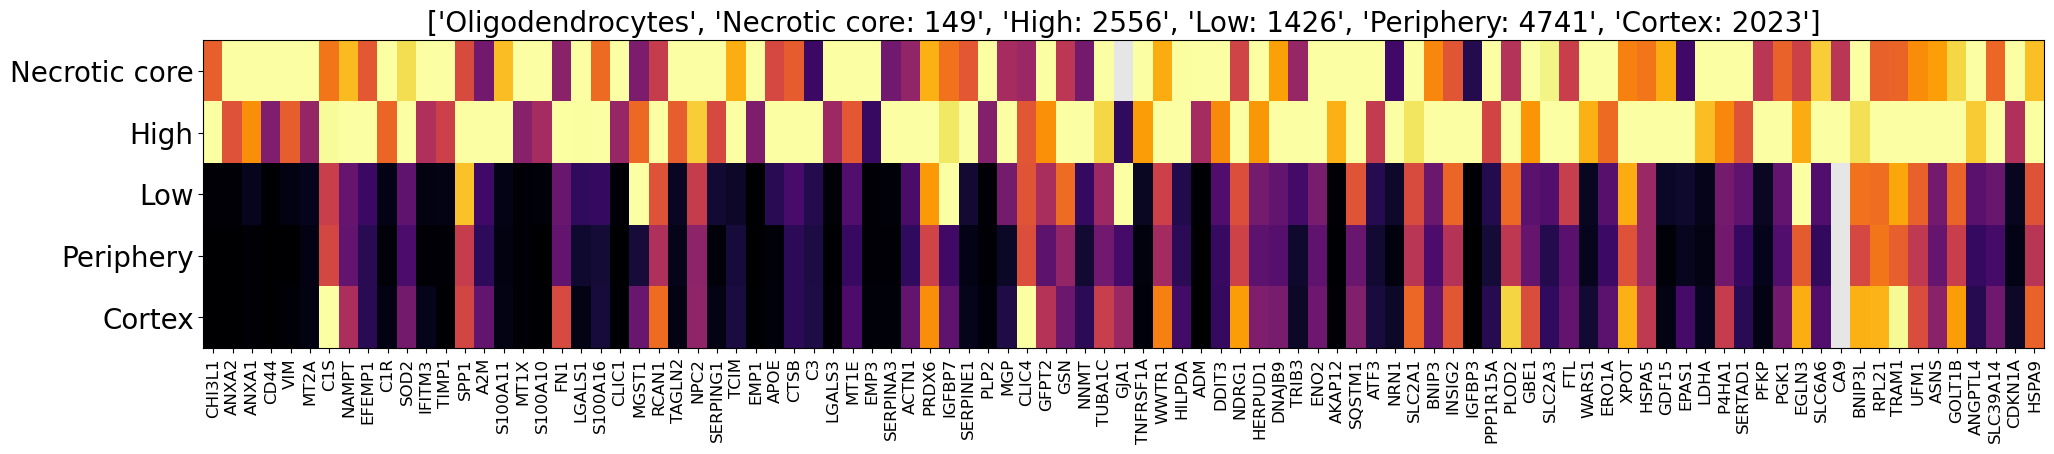

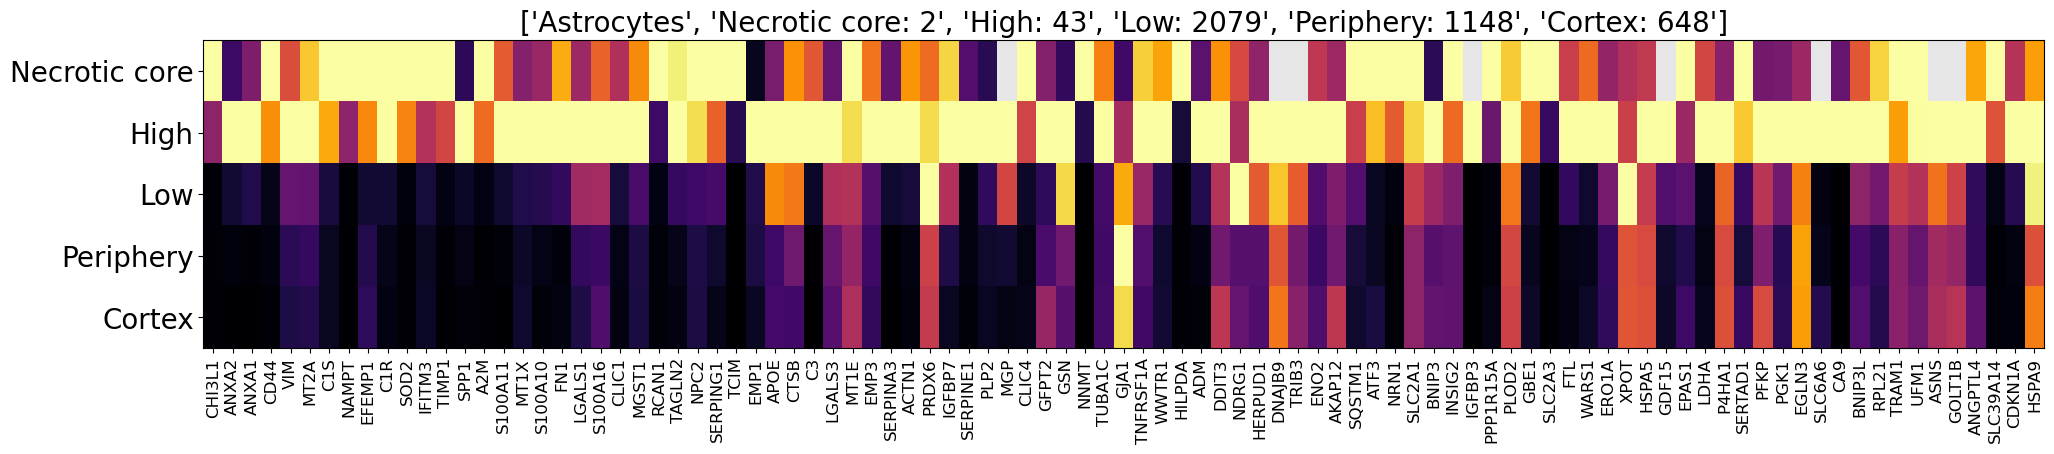

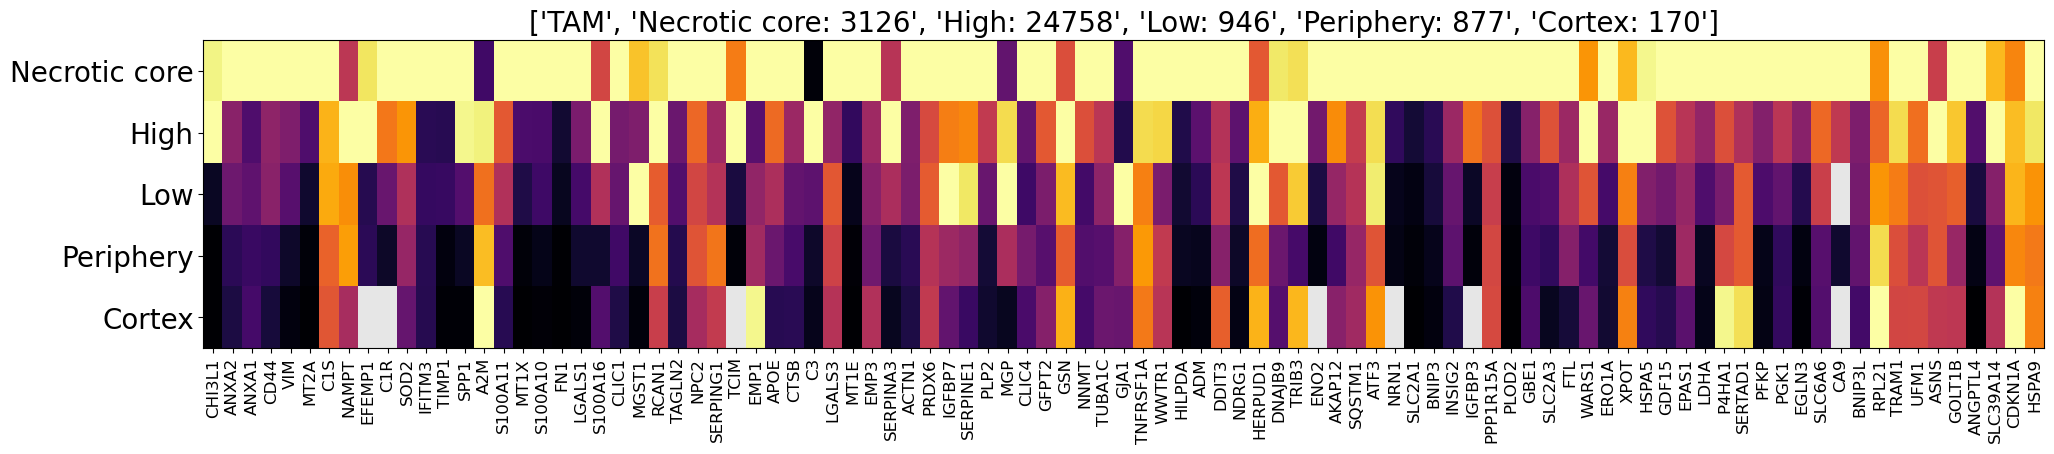

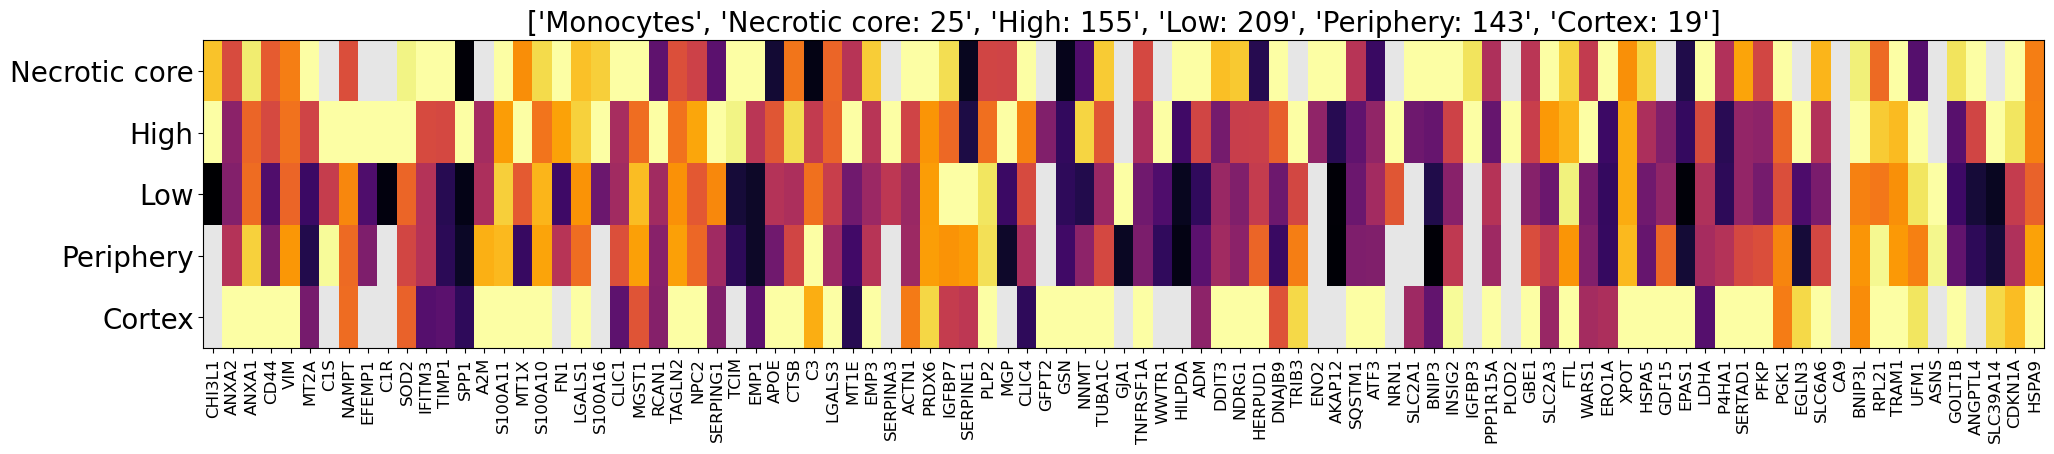

In [26]:
%%time
#Heatmap for all cell types, normalized internally. Print number of cells per location on top
celltype = ['Tumor', 'Oligodendrocytes', 'Astrocytes', 'TAM', 'Monocytes']
Samples = ['Necrotic core', 'High', 'Low', 'Periphery', 'Cortex'] #Zone/location
Samples = np.array(Samples, dtype=object)
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL040_TAM[ws.Fluorescence[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0: #Only proceed if cell type exist in location
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(unique_samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list): #check mean expression of every gene in cell type and zone
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(unique_samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040_TAM[ws.Fluorescence[:] == sample] == cell])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    G = xY
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno", vmax=1, interpolation= "nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=unique_samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None


## Extended figure 1

### Heatmap of the inferred CNV profiles (Extended fig 1c)

In [27]:
ad.var_names_make_unique()

In [28]:
#Change name
ad.var["chromosome"] = ad.var["Chromosome"]
ad.var["start"] = ad.var["Start"]
ad.var["end"] = ad.var["End"]
ad.var["ensg"] = ad.var["Accession"]

In [29]:
#Normalize and logaritmize
sc.pp.normalize_total(ad)
sc.pp.log1p(ad)

In [30]:
cnv.tl.infercnv(ad, window_size=500, exclude_chromosomes=('', 'GL000009.2', 'GL000194.1', 'GL000195.1', 'GL000205.2',
       'GL000213.1', 'GL000216.2', 'GL000218.1', 'GL000219.1',
       'GL000220.1', 'GL000225.1', 'KI270442.1', 'KI270711.1',
       'KI270713.1', 'KI270721.1', 'KI270726.1', 'KI270727.1',
       'KI270728.1', 'KI270731.1', 'KI270733.1', 'KI270734.1',
       'KI270744.1', 'KI270750.1','chrM','chrY'), reference_key="ManualAnnotationSL040",reference_cat=["Astrocytes", "Microglia","MgTAM", "Oligodendrocytes", "Endothelial"])

  0%|          | 0/28 [00:00<?, ?it/s]

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='Aneuploid'>,
 'gene_groups_ax': <Axes: >}

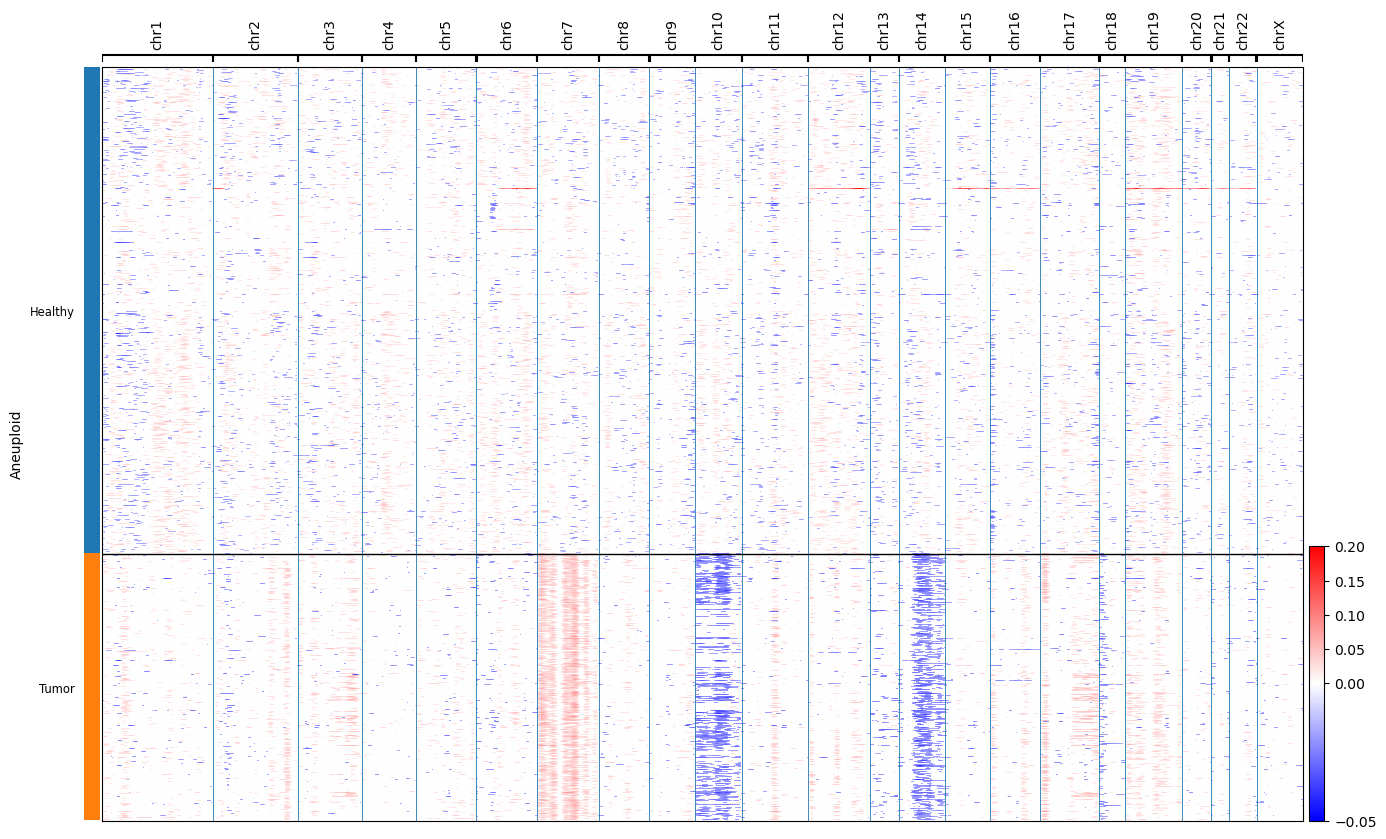

In [31]:
cnv.pl.chromosome_heatmap(ad, groupby="Aneuploid", show=False, cmap='bwr',vmin = -0.05, vmax = 0.2)

### Select Colors of choice tSNE cell types (Extended fig 1d)

In [32]:
col = []
FL = ws.ManualAnnotationSL040[:]
for x in FL:
    if x == 'Monocytes':
        col.append(Z[0])
    elif x == 'Macrophages':
        col.append(Z[1])
    elif x == 'MoTAM':
        col.append(Z[2])
    elif x == 'MgTAM':
        col.append(Z[3])
    elif x == 'Microglia':
        col.append(Z[4])
    elif x == 'Oligodendrocytes':
        col.append(Z[5])
    elif x == 'Astrocytes':
        col.append(Z[6])
    elif x == 'Tumor':
        col.append(Z[7])
    else:
        col.append(Z[8])

In [33]:
palette_classes = {'Astrocytes':'#4574b3',
 'B-cells': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Fibroblasts': [0.296875, 0.0, 0.359375],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM':  "#b36305",                
 'Monocytes': "#a580ad",
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Pericytes': [0.7578125, 0.0, 0.53125],
 'Tumor': "#74c493",
 'VSMC': [0.99609375, 0.640625, 0.01953125]}

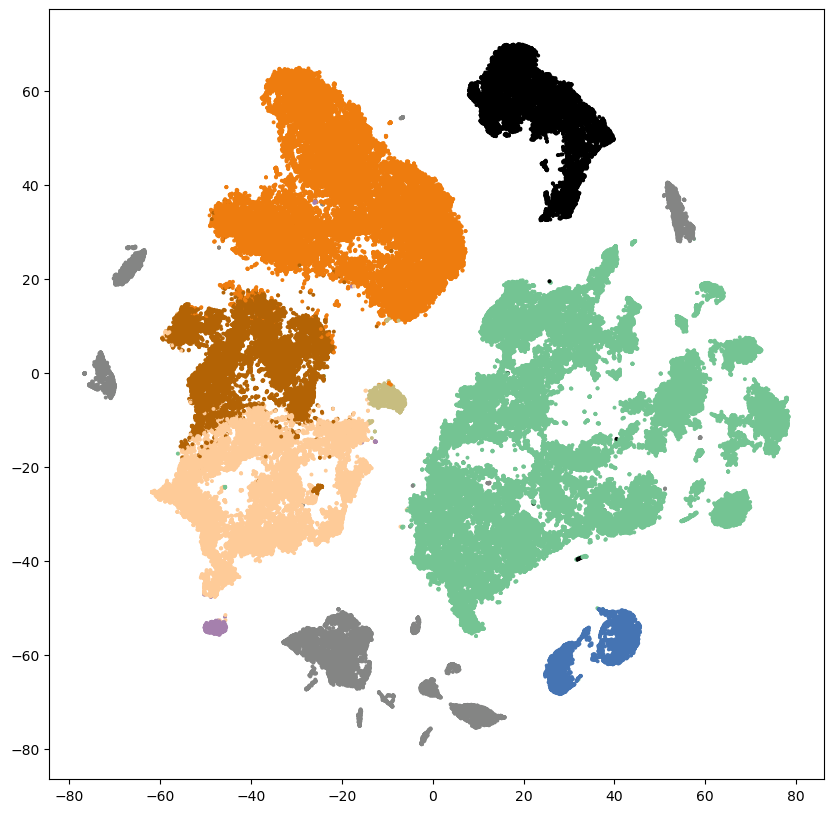

In [34]:
plt.figure(figsize=(10,10))
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c=col, s=8, lw=0, rasterized=True)

### Plot Neftel-states on tSNE (Extended fig 1d)

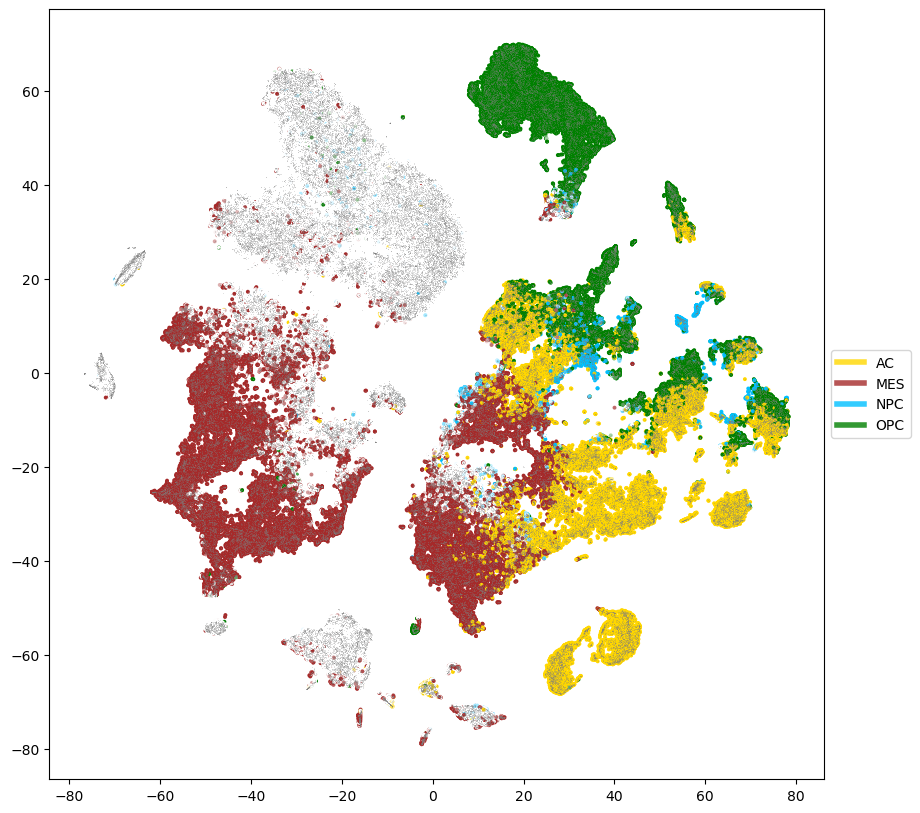

In [35]:
plt.figure(figsize=(10,10))
ac, mes, npc, opc = np.hsplit(ws.NeftelScore[:], 4)
cgplot.scatterm(ws.Embedding[:], c=[ac, mes, npc, opc], cmaps=["gold", "brown", "deepskyblue", "green"], labels=["AC", "MES", "NPC", "OPC"], s=8)
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c='gray', alpha=0.2, s=0.4, lw=0, rasterized=True)

### Select colors for sampling locations and plot on tSNE (Extended fig 1d)

In [36]:
Z = ["#ead5c0", # Cortex - gray
 "royalblue", #Periphery - blue
 "#B15297", #Low - purple
"deeppink", #High - pink
 "#000000"] #Necrotic core - black

In [37]:
col = []
FL = ws.Fluorescence[:]
for x in FL:
    if x == 'Cortex':
        col.append(Z[0])
    elif x == 'Periphery':
        col.append(Z[1])
    elif x == 'Low':
        col.append(Z[2])
    elif x == 'High':
        col.append(Z[3])
    else:
        col.append(Z[4])

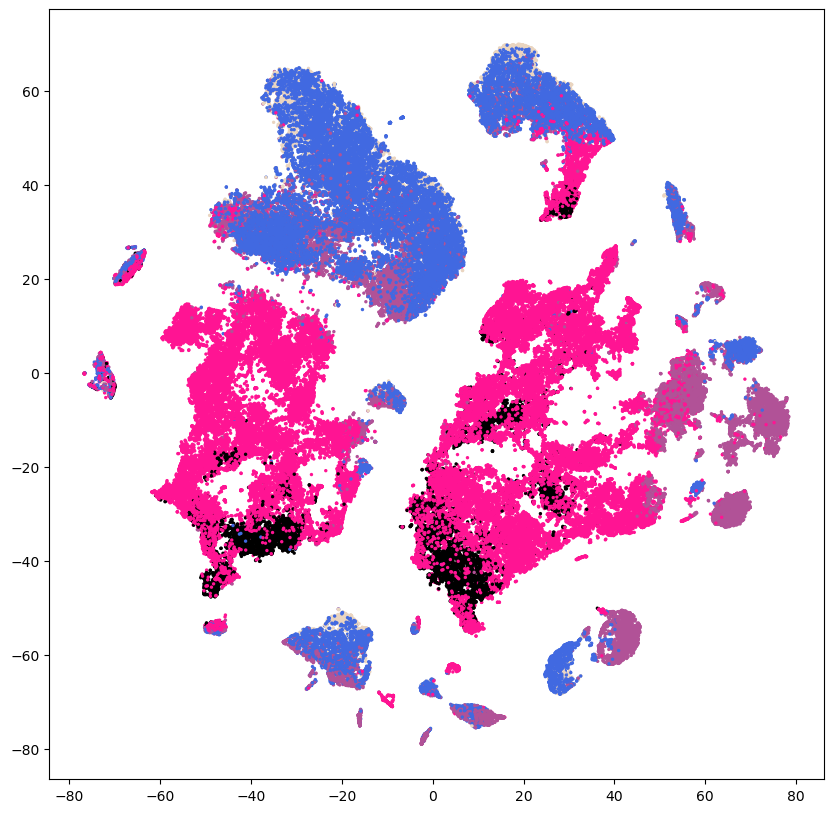

In [38]:
plt.figure(figsize=(10,10))
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c=col, s=6, lw=0, rasterized=True)

### Calc fraction of cell types (Extended fig 1e)

In [39]:
#Colors
Z =["#a580ad",
    "#c7bd80",
[0.99609375, 0.796875, 0.59765625],
 "#b36305", 
"#ee7c0e",
"#000000",
'#4574b3',
 "#74c493", 
'#848584'
]

CPU times: user 17.5 s, sys: 5.84 s, total: 23.4 s
Wall time: 33.4 s


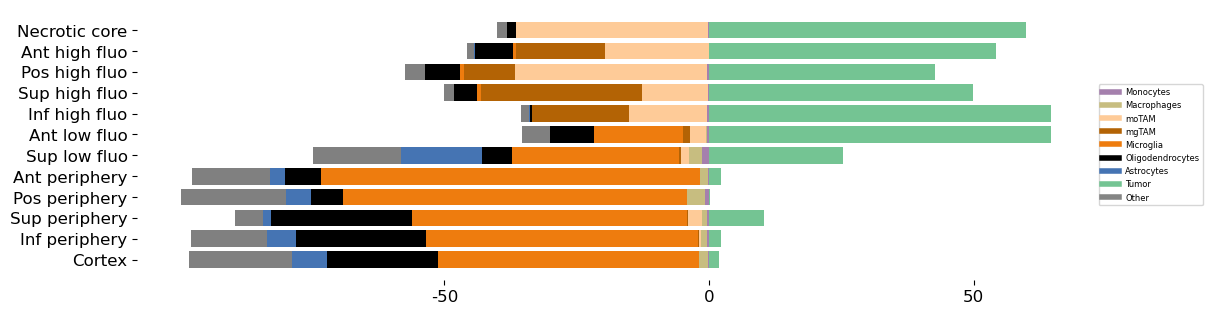

In [40]:
%%time
S = []
Samples = ['Necrotic core',
           'Ant high fluo', 'Pos high fluo','Sup high fluo', 'Inf high fluo',
           'Ant low fluo', 'Sup low fluo',
           'Ant periphery','Pos periphery','Sup periphery','Inf periphery', 
           'Cortex'
          ] #All 12 locations of sampling, zones and directions.
labels = np.unique(ws.ManualAnnotationSL040[:])  # all unique cell types
Samples = np.flip(Samples)
Samples = np.array(Samples, dtype=object)
unique_samples = Samples
for i, sample in enumerate(Samples):
    Man = ws.ManualAnnotationSL040[:][ws.Location[:] == sample] #All cells in location
    Sum = []
    for x in labels: #loop through all cell types and count total
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum) #total number cells
    for x in Sum: #calc percentage of total for all cell types
        roundedNumber = round(x/tot * 100, 3) #round and multiply by 100 in order to show percentage
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop(['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC','Tumor'], axis=1) #All non-malignant cell types except "other"
other_bars = df[['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC']] #other"
tumor_bars = df[["Tumor"]] #tumor cells
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(10, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True)  
ax1.set_xticklabels([-50,0,50],fontsize=12)
#Plot percentage of different cell types (bars horizontal)
for i, ct in enumerate(Right_order):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=palette_classes[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(other_bars):
    ax1.barh(unique_samples,height=0.8, width=-other_bars[ct],left=-left, color=[0.5, 0.5, 0.5])
    left += other_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=palette_classes[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in Z]
ax1.legend(hidden_lines,labels2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12) 
None

### Tumor cells, subtype fraction (Extended fig 1e)

CPU times: user 17.4 s, sys: 6.08 s, total: 23.5 s
Wall time: 33.4 s


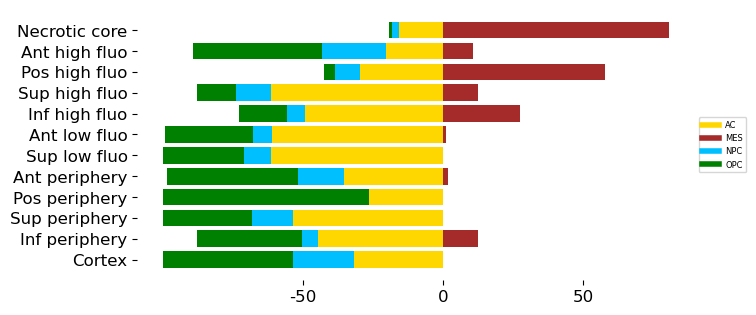

In [41]:
%%time
S = []
Samples = ['Necrotic core',
           'Ant high fluo', 'Pos high fluo','Sup high fluo', 'Inf high fluo',
           'Ant low fluo', 'Sup low fluo',
           'Ant periphery','Pos periphery','Sup periphery','Inf periphery', 
           'Cortex'
          ] #All 12 locations of sampling, zones and directions.
Samples = np.flip(Samples)
unique_samples = Samples
Samples = np.array(Samples, dtype=object)
A = ['AC', 'MES', 'NPC', 'OPC'] # all neftel states
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
    ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Location[:] == sample][ws.ManualAnnotationSL040[ws.Location[:] == sample] == 'Tumor'], 4)
    winnersAll = np.argmax([ac, mes, npc, opc], axis=0) #The subtype with the highest score of the four is assigned to the cell
    Man = np.hstack(labels[winnersAll])
    Sum = []
    for x in labels: #loop through all cell states and count total
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum) #total number tumor cells
    for x in Sum: #calc percentage of total for all cell types
        roundedNumber = round(x/tot * 100, 3) #round and multiply by 100 in order to show percentage
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop('MES', axis=1)
tumor_bars = df[["MES"]] #show MES-fraction separately
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True) 

ax1.set_xticklabels([-50,0,50],fontsize=12)
colors=["gold", "brown", "deepskyblue", "green"]
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(nontumor_bars):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=pcolors[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12) 
None

### % MES UMI contribution to total transcriptome across cell types and zones (Extended fig 1f)

In [42]:
#use cell type annotation in ws.ManualAnnotationSL040_Myeloid, here Macrophages, moTAMs are called 'Macrophages' and Microglia, MgTAMs called 'Microglia'
celltype = ['Astrocytes',
 'Endothelial',
 'Macrophages',
 'Microglia',    
 'Monocytes',
 'OPCs',
 'Oligodendrocytes',
 'Tumor']

In [43]:
%%time
#Calc fraction of UMIs from MES genes in cell types across zones
MES = gene_list
Fraction = []
for cell in celltype:
    cMES = 0
    nMES = 0
    hMES = 0
    lMES = 0
    pMES = 0
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Necrotic core'] == cell) < 15: #Only include location if 15 or more cells of specific cell type
        nMES = np.nan
        Total_n = np.nan
    else:
        Total_n = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Necrotic core'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Necrotic core'] == cell])
        for gene in MES:
            nMES = nMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Necrotic core'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Necrotic core'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'High'] == cell) < 15:
        hMES = np.nan
        Total_h = np.nan
    else:
        Total_h = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'High'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'High'] == cell])
        for gene in MES:
            hMES = hMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'High'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'High'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Low'] == cell) < 15:
        lMES = np.nan
        Total_l = np.nan
    else:    
        Total_l = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Low'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Low'] == cell])
        for gene in MES:
            lMES = lMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Low'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Low'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Periphery'] == cell) < 15:
        pMES = np.nan
        Total_p = np.nan
    else:   
        Total_p = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Periphery'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Periphery'] == cell])
        for gene in MES:
            pMES = pMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Periphery'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Periphery'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Cortex'] == cell) < 15:
        cMES = np.nan
        Total_c = np.nan
    else:   
        Total_c = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Cortex'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Cortex'] == cell])
        for gene in MES:
            cMES = cMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Cortex'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Cortex'] == cell])
    Fraction.append([nMES/Total_n,hMES/Total_h,lMES/Total_l, pMES/Total_p, cMES/Total_c])

CPU times: user 1h 36min 44s, sys: 31min 52s, total: 2h 8min 36s
Wall time: 3h 5min 34s


In [44]:
r = dict(zip(celltype, Fraction)) #Make dataframe
df = pd.DataFrame(r)
df = df.transpose()
df = df.rename(columns={0:"necrotic core", 1:"high", 2: "low", 3: "Periphery", 4: 'Cortex'}) #Rename columns (zone)
df = df.multiply(100) # display percentage
merg = df
df

,necrotic core,high,low,Periphery,Cortex
Astrocytes,NaN,11.075270,5.224462,2.811736,2.270910
Endothelial,NaN,4.026932,4.602787,3.346023,3.207619
Macrophages,13.311955,10.171339,7.628568,5.357856,2.522639
Microglia,NaN,7.122843,3.623755,2.548402,2.426639
Monocytes,4.212841,3.925778,3.562615,2.859624,2.829429
OPCs,NaN,4.140583,1.431501,0.691177,0.556746
Oligodendrocytes,3.884189,2.615107,1.318626,0.945555,0.709432
Tumor,12.507291,5.767425,1.647717,1.006576,0.704087


### Colors of choice (Extended fig 1f)

In [45]:
#Colors of choice
palette_classes = {'Astrocytes':'#4574b3',
 'B-cells': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM':  "#b36305",                
 'Monocytes': "#a580ad",
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Tumor': "#74c493"}

In [46]:
#Show cells with significant decrease
select = df.drop(df.index[[1,4]])
merg = select
select

,necrotic core,high,low,Periphery,Cortex
Astrocytes,NaN,11.075270,5.224462,2.811736,2.270910
Macrophages,13.311955,10.171339,7.628568,5.357856,2.522639
Microglia,NaN,7.122843,3.623755,2.548402,2.426639
OPCs,NaN,4.140583,1.431501,0.691177,0.556746
Oligodendrocytes,3.884189,2.615107,1.318626,0.945555,0.709432
Tumor,12.507291,5.767425,1.647717,1.006576,0.704087


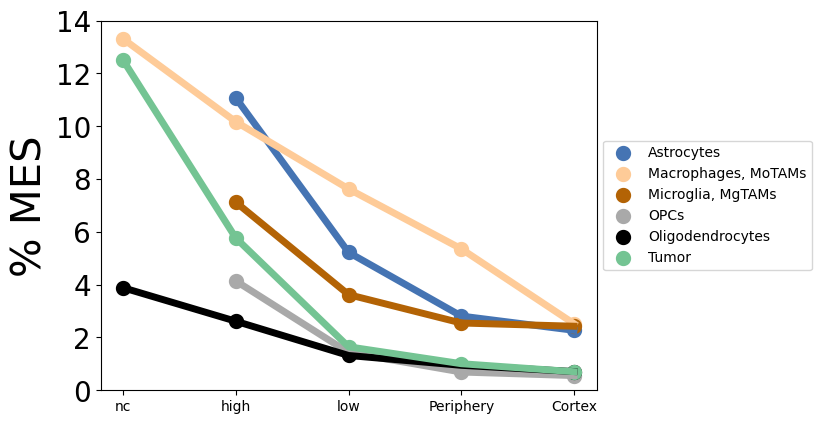

In [47]:
numb = merg.columns
numb = ['nc', 'high', 'low', 'Periphery','Cortex'] # nc = Necrotic core
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='#4574b3',linewidth=5)
plt.scatter(numb, merg.iloc[1],label=('Macrophages, MoTAMs'), color=[0.99609375, 0.796875, 0.59765625],linewidth=5)
plt.scatter(numb, merg.iloc[2],label=('Microglia, MgTAMs'), color="#b36305",linewidth=5)
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color= 'darkgrey',linewidth=5)
plt.scatter(numb, merg.iloc[4],label=(merg.index[4]), color="#000000",linewidth=5)
plt.scatter(numb, merg.iloc[5],label=(merg.index[5]), color="#74c493",linewidth=5)

plt.plot(numb, merg.iloc[0], color='#4574b3', linewidth=5)
plt.plot(numb, merg.iloc[1], color=[0.99609375, 0.796875, 0.59765625],linewidth=5)
plt.plot(numb, merg.iloc[2], color= "#b36305",linewidth=5) 
plt.plot(numb, merg.iloc[3], color='darkgrey',linewidth=5)
plt.plot(numb, merg.iloc[4], color="#000000",linewidth=5)
plt.plot(numb, merg.iloc[5], color="#74c493",linewidth=5)

plt.ylim(0, 14)
plt.legend(loc='center left',bbox_to_anchor=(1, 0.5))
plt.ylabel('% MES', fontsize=30)
plt.xticks(numb)
plt.yticks(fontsize=20)
None

In [48]:
#Show cells with no or minimal decrease
select2 = df.drop(df.index[[0,2,3,5,6,7]])
merg = select2
select2

,necrotic core,high,low,Periphery,Cortex
Endothelial,NaN,4.026932,4.602787,3.346023,3.207619
Monocytes,4.212841,3.925778,3.562615,2.859624,2.829429


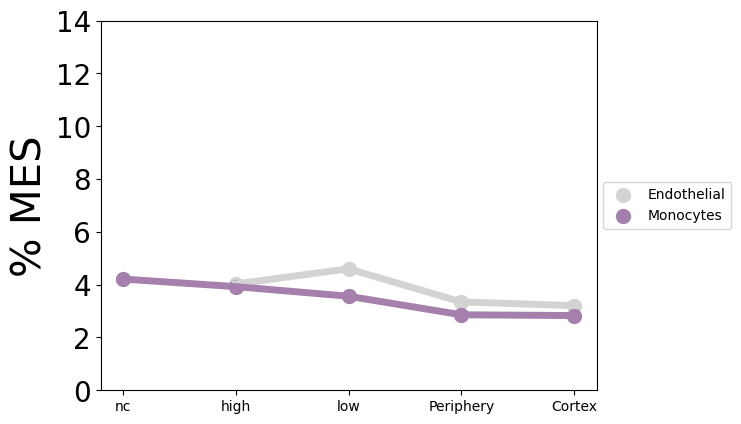

In [49]:
merg = select2
numb = merg.columns
numb = ['nc', 'high', 'low', 'Periphery','Cortex'] # nc = Necrotic core
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='lightgrey',linewidth=5)
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color="#a580ad",linewidth=5)
plt.plot(numb, merg.iloc[0], color='lightgrey', linewidth=5)
plt.plot(numb, merg.iloc[1], color="#a580ad",linewidth=5)
plt.ylim(0, 14)
plt.legend(loc='center left',bbox_to_anchor=(1, 0.5))
#plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=30)
#plt.title('Cell types', fontsize=25)
plt.xticks(numb)
plt.yticks(fontsize=20)
None

### Colormap for Macrophage-lineage (Macrophages, moTAMs) across all MES-genes and zones (Extended fig 1g)

CPU times: user 13min 49s, sys: 4min 27s, total: 18min 16s
Wall time: 26min 17s


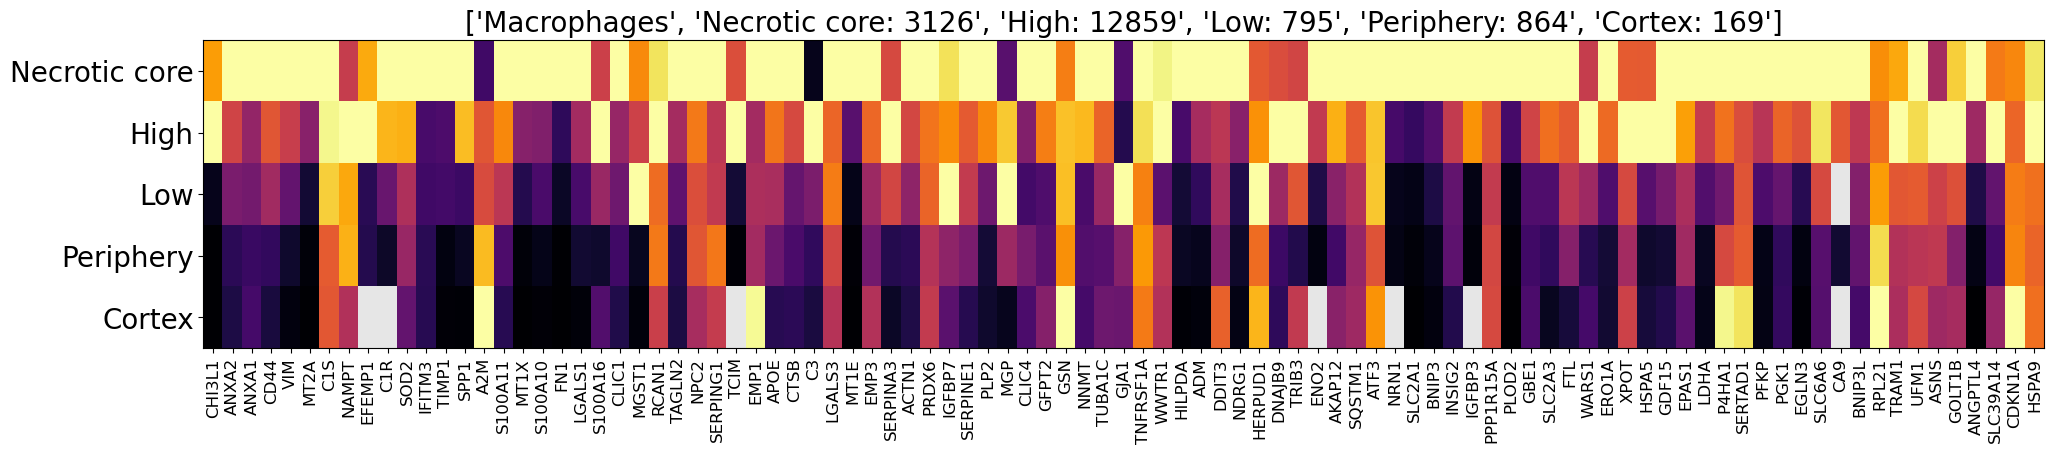

In [50]:
%%time
#Colormap for all cell types, normalized internally, inferno. Print number of cells per location on top
celltype = ['Macrophages']
Samples = ['Necrotic core', 'High', 'Low', 'Periphery','Cortex']
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0:
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(Samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list):
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(unique_samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == 'Macrophages'])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno",vmin=0, vmax=1, interpolation="nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=unique_samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None

### Colormap for Microglia-lineage (Microglia, mgTAMs) across all MES-genes and zones (Extended fig 1g)

CPU times: user 11min 14s, sys: 3min 41s, total: 14min 55s
Wall time: 21min 35s


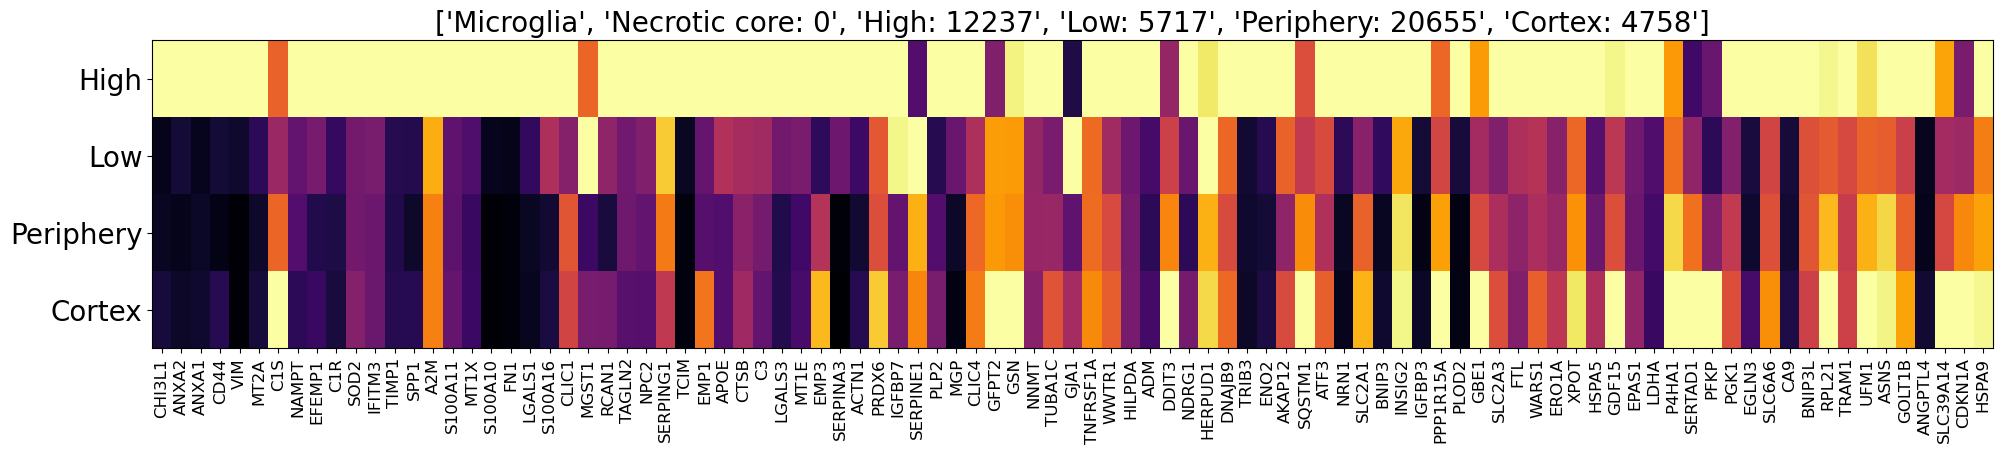

In [51]:
%%time
#Colormap for all cell types, normalized internally, inferno. Print number of cells per location on top
celltype = ['Microglia']
Samples = ['Necrotic core','High', 'Low', 'Periphery','Cortex']
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0:
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(unique_samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list):
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(unique_samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == 'Microglia'])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno",vmin=0, vmax=1, interpolation="nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=unique_samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None